In [20]:
import pandas as pd
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS
from sklearn.feature_extraction.text import CountVectorizer
from wordcloud import WordCloud, ImageColorGenerator
from PIL import Image
import matplotlib.pyplot as plt
import numpy as np
from sklearn.feature_extraction.text import TfidfVectorizer

In [21]:
#1. Import Dataset

df=pd.read_csv("all_essays_sentences_only.csv")

In [22]:
# Displaying Data

df=df.drop(columns=["Unnamed: 1"])
df=df.drop(columns=["Unnamed: 2"])
df=df.drop(columns=["Unnamed: 3"])
df=df.drop(columns=["Unnamed: 4"])

rows, cols=df.shape
print(df.head())

print("Rows:", rows)
print("Columns:", cols)


                                            sentence
0  Can one abandon human nature and remain morall...
1  In Macbeth, Shakespeare initially depicts Lady...
2  She embraces the devilish nature of the evil s...
3  She then demands to not let “heaven peep” from...
4  Although Lady Macbeth had seemingly no qualms ...
Rows: 1067
Columns: 1


In [23]:
#2. Cleaned Text

df["cleaned_text"]=df["sentence"].str.lower()
df[["cleaned_text"]].head()

,cleaned_text
0,can one abandon human nature and remain morall...
1,"in macbeth, shakespeare initially depicts lady..."
2,she embraces the devilish nature of the evil s...
3,she then demands to not let “heaven peep” from...
4,although lady macbeth had seemingly no qualms ...


2. Lowercase text helps make analysis easier by preventing duplicate versions of the same words, making counting easier.


In [24]:
#3. Cleaned Puncutation

df["cleaned_text"]=df["cleaned_text"].str.replace(r"[^a-z\s]", " ", regex=True)
df["cleaned_text"]=df["cleaned_text"].str.replace(r"\s+", " ", regex=True)
df["cleaned_text"]=df["cleaned_text"].str.strip()

print(f' Original: {df["sentence"].iloc[0]}')
print(f' Cleaned: {df["cleaned_text"].iloc[0]}')


 Original: Can one abandon human nature and remain morally undisturbed at the same time (prepositional phrase), or are the two intrinsically bound?
 Cleaned: can one abandon human nature and remain morally undisturbed at the same time prepositional phrase or are the two intrinsically bound


In [25]:
#4. Tokenization

df["tokens"]=df["cleaned_text"].str.split()
df["tokens"].head()

0    [can, one, abandon, human, nature, and, remain...
1    [in, macbeth, shakespeare, initially, depicts,...
2    [she, embraces, the, devilish, nature, of, the...
3    [she, then, demands, to, not, let, heaven, pee...
4    [although, lady, macbeth, had, seemingly, no, ...
Name: tokens, dtype: object

4. Tokenization splits each sentence into a list of words


In [26]:
#5. Removing stop words

stop_words = ENGLISH_STOP_WORDS

df["tokens_not_stop"]=df["tokens"].apply(lambda words: [word for word in words if word not in stop_words])
df["tokens_not_stop"].head()


0    [abandon, human, nature, remain, morally, undi...
1    [macbeth, shakespeare, initially, depicts, lad...
2    [embraces, devilish, nature, evil, sources, or...
3    [demands, let, heaven, peep, enshrouding, clou...
4    [lady, macbeth, seemingly, qualms, damned, exe...
Name: tokens_not_stop, dtype: object

In [27]:
#6. Combine into documents

df=df.reset_index(drop=True)
df["joined_tokens"]=df["tokens_not_stop"].apply(lambda x: " ".join(x))
df["group"]=df.index//10

documents=(
    df.groupby("group")["joined_tokens"]
    .apply(" ".join)
    .reset_index(name="document")
)

documents.head()

,group,document
0,0,abandon human nature remain morally undisturbe...
1,1,furthermore macbeth pressured wife kill guards...
2,2,later admission hell murky underscores reversa...
3,3,lady macbeth s pain staking mental depreciatio...
4,4,belief gives meaning gatsby s transformation w...


6. Larger documents are more useful because more words mean more data to find clearer patterns and draw conclusions from. Small sentences alone may not contain enough information and words might have less accurate weights because the number of important words might be overshadowed / equate to the stop or more useless filler words.

In [28]:
#7. 20 Most Common Words
all_words=" ".join(documents["document"]).split()
word_counts=pd.Series(all_words).value_counts()
word_counts.head(20)

s           194
thiago      134
t           114
alab         90
dvir         70
want         52
just         51
like         50
math         47
love         41
time         38
way          35
problem      32
life         31
didn         31
work         31
problems     31
know         31
physics      30
macbeth      29
Name: count, dtype: int64

7. While the word themes may vary a lot because I inserted very starkly contrasting types of works (for example, the document does not only contain analytical writing because I have a lengthy creative story and summer camp application answers in it as well), one notion that I can take away is that I have a tendency to use the words "like" and "just" a lot in my works, probably because it is a comfortable way to get an idea across when it does not feel entirely stable despite their being informal jargon.

In [29]:
#8. Bag of Words
count_vectorizer=CountVectorizer()
bow_matrix=count_vectorizer.fit_transform(documents["document"])
bow_df=pd.DataFrame(bow_matrix.toarray(), columns=count_vectorizer.get_feature_names_out())

print(bow_df)


     abab  aback  abandon  abandoning  abilities  ability  able  abnormal  \
0       0      0        2           0          0        0     0         0   
1       0      0        0           0          0        1     0         0   
2       0      0        0           0          0        0     0         0   
3       0      0        0           0          0        0     0         0   
4       0      0        0           0          0        0     0         0   
..    ...    ...      ...         ...        ...      ...   ...       ...   
102     0      0        0           0          0        1     0         0   
103     0      0        0           0          0        0     0         0   
104     0      0        0           0          0        1     0         0   
105     0      0        0           0          0        0     0         0   
106     0      0        0           0          0        1     0         0   

     abrupt  absence  ...  yes  young  younger  yu  yusupov  zero  zinc  \


9. The shape of my bag of words looks like a huge table with many columns and rows. I have 3525 unique words.

In [30]:
#10. Highest Total Word Counts

word_totals=bow_matrix.sum(axis=0)
vocab=count_vectorizer.get_feature_names_out()
word_count_df=pd.DataFrame({
    "word": vocab,
    "count": word_totals.tolist()[0]
})

word_count_df=word_count_df.sort_values(
    by="count",
    ascending=False
)

word_count_df.head(20)


,word,count
3162,thiago,134
82,alab,90
924,dvir,70
3410,want,52
1720,just,51
1819,like,50
1916,math,47
1868,love,41
3190,time,38
3427,way,35


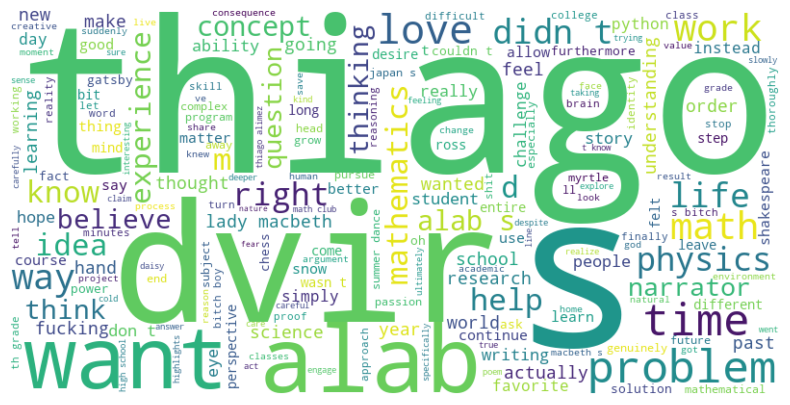

In [32]:
#11. Word Cloud

text = " ".join(documents["document"])
wordcloud = WordCloud(
    width=800,
    height=400,
    background_color="white"
).generate(text)

plt.figure(figsize=(10,5))
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")
plt.show()

In [37]:
#12. TDF

tfidf_vectorizer=TfidfVectorizer()
tfidf_matrix=tfidf_vectorizer.fit_transform(documents["document"])
tfidf_df=pd.DataFrame(tfidf_matrix.toarray(),columns=tfidf_vectorizer.get_feature_names_out())

print(tfidf_df)

     abab  aback   abandon  abandoning  abilities   ability  able  abnormal  \
0     0.0    0.0  0.109752         0.0        0.0  0.000000   0.0       0.0   
1     0.0    0.0  0.000000         0.0        0.0  0.031124   0.0       0.0   
2     0.0    0.0  0.000000         0.0        0.0  0.000000   0.0       0.0   
3     0.0    0.0  0.000000         0.0        0.0  0.000000   0.0       0.0   
4     0.0    0.0  0.000000         0.0        0.0  0.000000   0.0       0.0   
..    ...    ...       ...         ...        ...       ...   ...       ...   
102   0.0    0.0  0.000000         0.0        0.0  0.073577   0.0       0.0   
103   0.0    0.0  0.000000         0.0        0.0  0.000000   0.0       0.0   
104   0.0    0.0  0.000000         0.0        0.0  0.068354   0.0       0.0   
105   0.0    0.0  0.000000         0.0        0.0  0.000000   0.0       0.0   
106   0.0    0.0  0.000000         0.0        0.0  0.075293   0.0       0.0   

     abrupt  absence  ...  yes     young   younger 

12. While simple counting only measures frequency, TF-IDF gives heavier weight to unique important words and lowers importance of overly common words.


In [39]:
#13. Highest Average TF-IDF Scores

tfidf_words=tfidf_vectorizer.get_feature_names_out()
avg_tfidf=tfidf_matrix.mean(axis=0)
tfidf_df = pd.DataFrame({
    "word": tfidf_words,
    "avg_tfidf": avg_tfidf.tolist()[0]
})

tfidf_df=tfidf_df.sort_values(
    by="avg_tfidf",
    ascending=False
)

tfidf_df.head(20)

,word,avg_tfidf
3162,thiago,0.060512
82,alab,0.048026
924,dvir,0.041476
1720,just,0.026702
1819,like,0.026216
3410,want,0.025787
1916,math,0.024253
1744,know,0.022229
822,didn,0.020481
2642,right,0.020288


13. It seems that names and casual connecting words such as "just" and "like" are very important to my writing. I assume this is because a prominent work added to the documnent was a lengthy reactive story.

In [41]:
#14. Bag of Words vs TF-IDF

print(word_count_df.head(20))
print(tfidf_df.head(20))

          word  count
3162    thiago    134
82        alab     90
924       dvir     70
3410      want     52
1720      just     51
1819      like     50
1916      math     47
1868      love     41
3190      time     38
3427       way     35
2371   problem     32
3482      work     31
822       didn     31
1814      life     31
2372  problems     31
1744      know     31
2258   physics     30
2642     right     29
2717    school     29
1877   macbeth     29
          word  avg_tfidf
3162    thiago   0.060512
82        alab   0.048026
924       dvir   0.041476
1720      just   0.026702
1819      like   0.026216
3410      want   0.025787
1916      math   0.024253
1744      know   0.022229
822       didn   0.020481
2642     right   0.020288
2371   problem   0.019531
821        did   0.019486
3190      time   0.018522
2258   physics   0.018308
3427       way   0.018305
1868      love   0.017454
2372  problems   0.017187
1297   fucking   0.017077
1814      life   0.016925
1358     going   0

14. Overall, the top ten words from each table are almost identical. Names appear to be very distinctive and meaningul in both too.

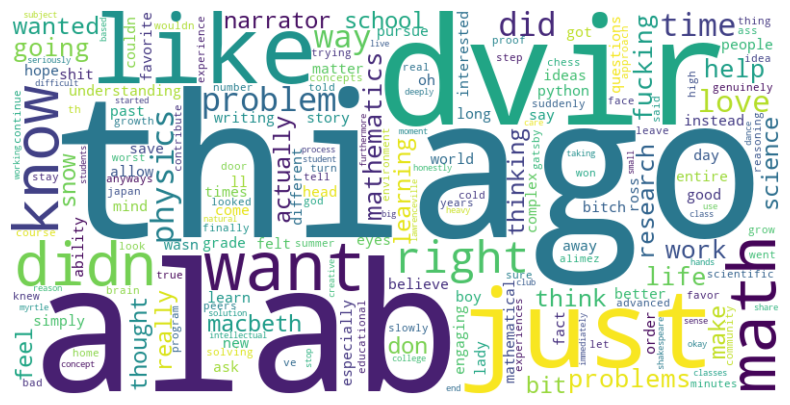

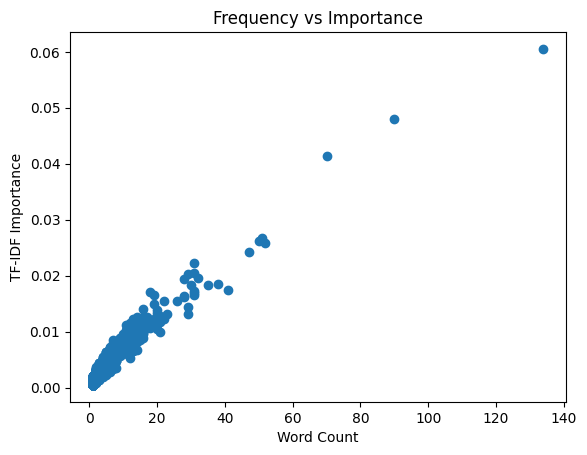

In [50]:
#15. Word Cloud and Scatter Plot of TF-IDF

tfidf_vectorizer=TfidfVectorizer(stop_words="english")
tfidf_matrix=tfidf_vectorizer.fit_transform(documents["document"])
word_scores=tfidf_matrix.sum(axis=0)
tfidf_scores={
    word: word_scores[0, idx]
    for word, idx in tfidf_vectorizer.vocabulary_.items()
}
text=" ".join(documents["document"])
wordcloud=WordCloud(
    width=800,
    height=400,
    background_color="white"
).generate_from_frequencies(tfidf_scores)

plt.figure(figsize=(10,5))
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")
plt.show()


compare_df=word_count_df.merge(tfidf_df,on="word")
plt.scatter(compare_df["count"],compare_df["avg_tfidf"])

plt.xlabel("Word Count")
plt.ylabel("TF-IDF Importance")
plt.title("Frequency vs Importance")
plt.show()


16. My text analysis is a bit skewed due to the very lengthy creative story that ended up being my longest piece of work in the document. Nonetheless, it still revealed that I am a passionate writer when it comes to fiction, and I prefer making creative literature over analytical essays. Moreover, I lean towards using casual language for the most part in my writing, and I also have a tendency to talk about my passions--for example, math and physics.